In [1]:
import pandas as pd
from sqlalchemy import create_engine

ModuleNotFoundError: No module named 'pandas'

In [2]:
%pip install pandas sqlalchemy psycopg2-binary

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.0 MB 704.0 kB/s eta 0:00:14
   -- ------------------------------------- 0.5/10.0 MB 704.0 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/10.0 MB 737.1 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/10.0 MB 765.1 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/10.0 MB 765.1 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/10.0 MB 791.3 kB/s eta 0:00:11
   ------ --------------------------------- 1.6/10.0 MB 826.8 kB/s eta 0:00:11
   ------- -------------------------------- 1.8/10.0 MB 863.9 kB/s eta 0:00:10
   -------- ------------------------------- 2.1/10.0 MB 895.1 kB/s eta 0:00:09
   ------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import pandas as pd
from sqlalchemy import create_engine

In [5]:
engine = create_engine(
    "postgresql+psycopg2://postgres:Ilvval22@@@localhost:5432/world"
)

In [5]:
query = """
SELECT
    c.name AS country,
    COUNT(cl.language) AS official_languages
FROM country AS c
JOIN countrylanguage AS cl
    ON c.code = cl.countrycode
WHERE cl.isofficial = 'T'
GROUP BY c.name
HAVING COUNT(cl.language) > 2
ORDER BY official_languages DESC;
"""

In [6]:
df = pd.read_sql(query, engine)

OperationalError: (psycopg2.OperationalError) connection to server on socket "@@localhost/.s.PGSQL.5432" failed: Invalid argument (0x00002726/10022)
	Is the server running locally and accepting connections on that socket?

(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [7]:
from sqlalchemy import create_engine, URL

url = URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password="YOUR_NEW_PASSWORD",
    host="localhost",
    port=5432,
    database="world"
)

engine = create_engine(url)

In [8]:
from sqlalchemy import create_engine, URL

url = URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password="Ilvval22@@",
    host="localhost",
    port=5432,
    database="world"
)

engine = create_engine(url)

In [9]:
df = pd.read_sql(query, engine)

In [10]:
display(df)

,country,official_languages
0,Switzerland ...,4
1,South Africa ...,4
2,Vanuatu ...,3
3,Belgium ...,3
4,Luxembourg ...,3
5,Peru ...,3
6,Bolivia ...,3
7,Singapore ...,3


In [11]:
query = """
SELECT
    c.name AS name,
    COUNT(cl.language) AS num_languages
FROM country AS c
JOIN countrylanguage AS cl
    ON c.code = cl.countrycode
WHERE cl.isofficial = 'T'
GROUP BY c.name
HAVING COUNT(cl.language) > 2
ORDER BY num_languages DESC;
"""

In [12]:
df = pd.read_sql(query, engine)

In [13]:
df.plot(
    kind="bar",
    x="name",
    y="num_languages"
)

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

In [14]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.5 MB 1.4 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.5 MB 1.5 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.5 MB 1.6 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.5 MB 1.7 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.5 MB 1.8 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.5 MB 1.8 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.5 MB 1.9 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.5 MB 2.0 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.5 MB 2.1 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.5 MB 2.1 MB/s eta 0:00:03
   -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


<Axes: xlabel='name'>

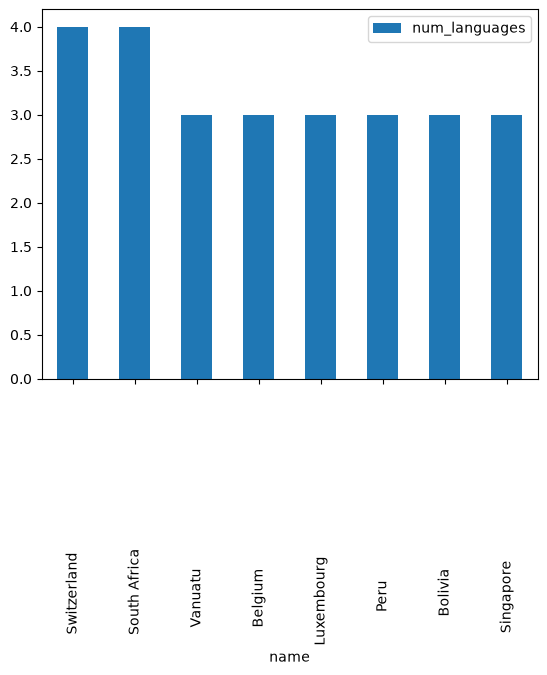

In [15]:
df.plot(
    kind="bar",
    x="name",
    y="num_languages",
    rot=90
)

In [9]:
query_spanish = """
SELECT
    c.name AS country,
    COUNT(cl.language) AS official_languages
FROM country AS c
JOIN countrylanguage AS cl
    ON c.code = cl.countrycode
WHERE cl.isofficial = 'T'
GROUP BY c.name
HAVING COUNT(cl.language) > 2
    AND SUM(CASE WHEN cl.language = 'Spanish' THEN 1 ELSE 0 END) > 0
ORDER BY official_languages DESC;
"""

df_spanish = pd.read_sql(query_spanish, engine)

df_spanish

,country,official_languages
0,Peru ...,3
1,Bolivia ...,3


In [2]:
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

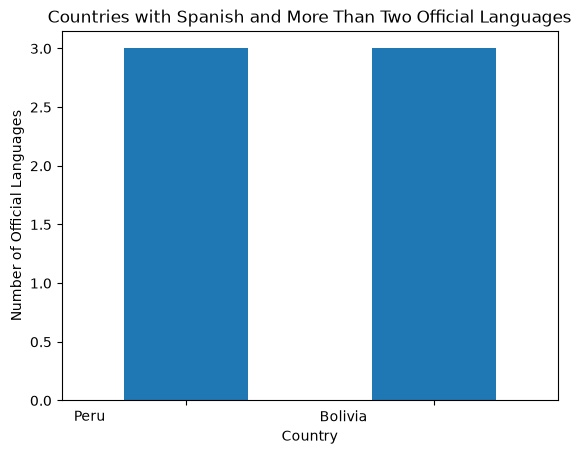

In [10]:
df_spanish.plot(
    kind="bar",
    x="country",
    y="official_languages",
    legend=False
)

plt.title("Countries with Spanish and More Than Two Official Languages")
plt.xlabel("Country")
plt.ylabel("Number of Official Languages")
plt.xticks(rotation=0)

plt.show()